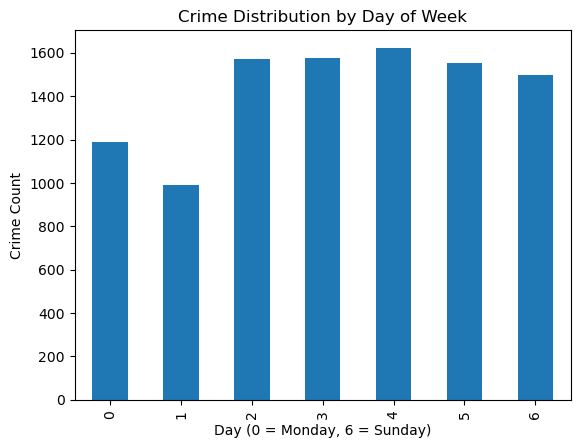

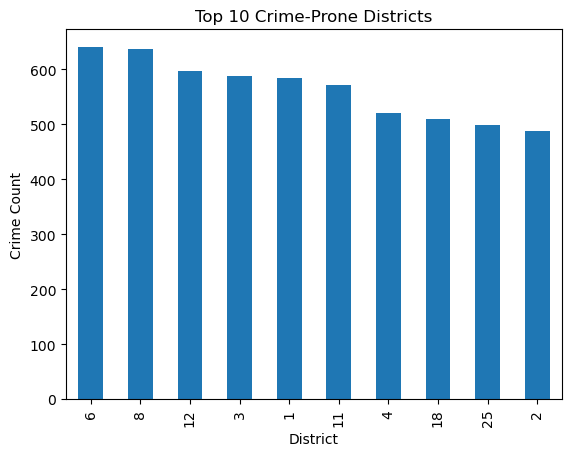


Objective 1: Arrest Prediction
Logistic Regression    Accuracy : 0.8365
SVM                    Accuracy : 0.8365
Random Forest          Accuracy : 0.7875
AdaBoost               Accuracy : 0.8365
Gradient Boosting      Accuracy : 0.8365

Objective 2: Domestic Crime Prediction
Logistic Regression    Accuracy : 0.8060
SVM                    Accuracy : 0.8060
Random Forest          Accuracy : 0.7490
AdaBoost               Accuracy : 0.8060
Gradient Boosting      Accuracy : 0.8060

Objective 3: Weekend Crime Prediction
Logistic Regression    Accuracy : 0.6930
SVM                    Accuracy : 0.6930
Random Forest          Accuracy : 0.6525
AdaBoost               Accuracy : 0.6930
Gradient Boosting      Accuracy : 0.6910

Objective 4: High Risk Hour Prediction
Logistic Regression    Accuracy : 0.7305
SVM                    Accuracy : 0.7305
Random Forest          Accuracy : 0.7230
AdaBoost               Accuracy : 0.7305
Gradient Boosting      Accuracy : 0.7305

Objective 5: Crime Severity 

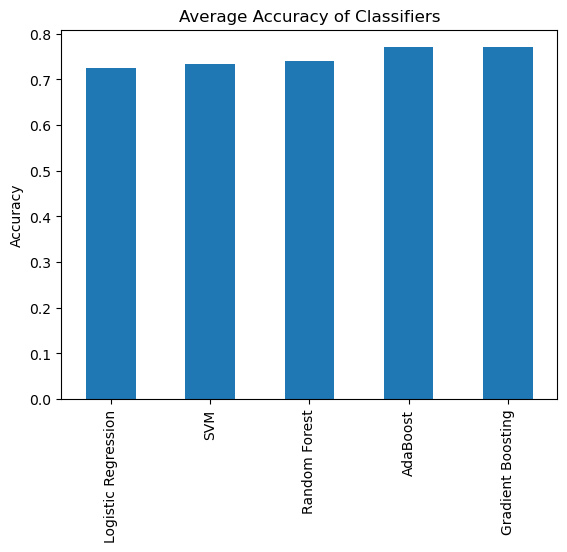

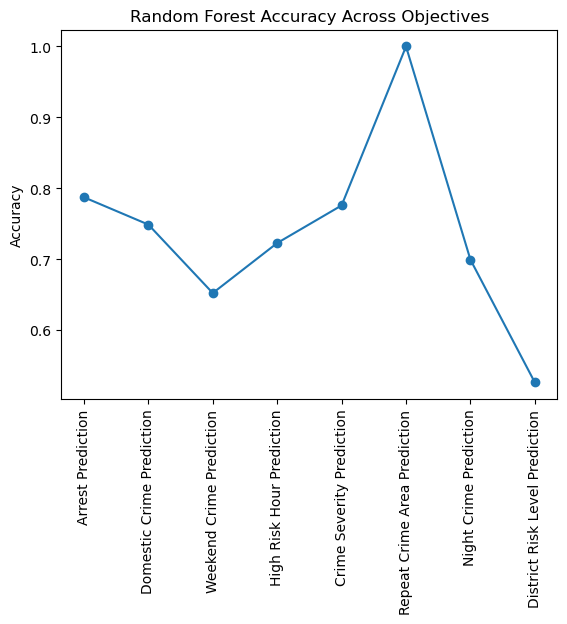

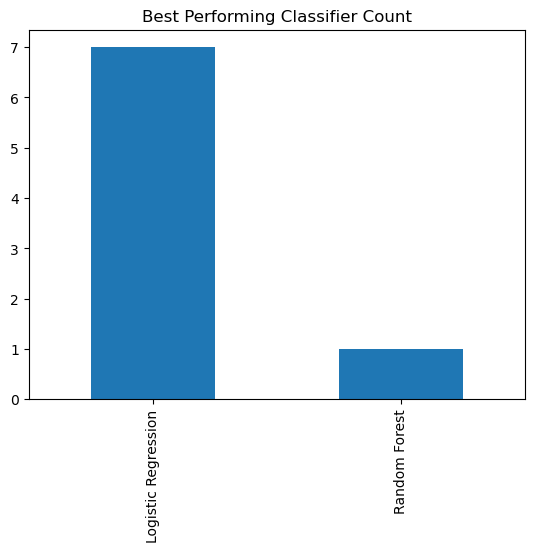

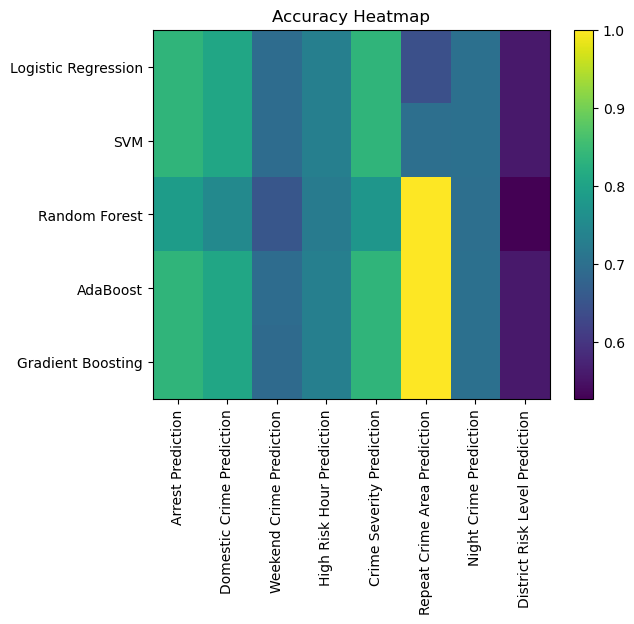

In [7]:
# CHICAGO CRIME PREDICTIVE ANALYTICS – FULL PROJECT
# 8 OBJECTIVES | 5 CLASSIFIERS | PRINT + 4 GRAPHS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# LOAD DATA
df = pd.read_csv(r"C:\Users\HP\Downloads\Crimes_-_2001_to_Present.csv")
df = df.dropna(subset=['District', 'Date'])

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Domestic'] = df['Domestic'].astype(int)
df['Arrest'] = df['Arrest'].astype(int)

# EDA (ADDED ONLY – NO OTHER CODE CHANGED)

# EDA 1: Crime Distribution by Day of Week
plt.figure()
df['DayOfWeek'].value_counts().sort_index().plot(kind='bar')
plt.title("Crime Distribution by Day of Week")
plt.xlabel("Day (0 = Monday, 6 = Sunday)")
plt.ylabel("Crime Count")
plt.show()

# EDA 2: Top 10 Crime-Prone Districts
plt.figure()
df['District'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crime-Prone Districts")
plt.xlabel("District")
plt.ylabel("Crime Count")
plt.show()

# CLASSIFIERS (LOGISTIC REGRESSION ADDED)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}
# COMMON FUNCTION (PRINTS RESULTS)
def run_objective(X, y, title):

    print("\n" + "="*60)
    print(title)
    print("="*60)

    if y.nunique() < 2:
        print("❌ Skipped (Only one class present)")
        return None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    scores = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        scores[name] = acc
        print(f"{name:22s} Accuracy : {acc:.4f}")

    return scores
# 8 OBJECTIVES
results = {}

results["Arrest Prediction"] = run_objective(
    df[['District', 'Hour', 'DayOfWeek', 'Domestic']],
    df['Arrest'],
    "Objective 1: Arrest Prediction"
)

results["Domestic Crime Prediction"] = run_objective(
    df[['District', 'Hour', 'DayOfWeek']],
    df['Domestic'],
    "Objective 2: Domestic Crime Prediction"
)

df['Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
results["Weekend Crime Prediction"] = run_objective(
    df[['District', 'Hour', 'Domestic']],
    df['Weekend'],
    "Objective 3: Weekend Crime Prediction"
)

df['HighRiskHour'] = (df['Hour'] >= 18).astype(int)
results["High Risk Hour Prediction"] = run_objective(
    df[['District', 'DayOfWeek', 'Domestic']],
    df['HighRiskHour'],
    "Objective 4: High Risk Hour Prediction"
)

df['Severity'] = np.where(df['Arrest'] == 1, 2, 1)
results["Crime Severity Prediction"] = run_objective(
    df[['District', 'Hour', 'DayOfWeek']],
    df['Severity'],
    "Objective 5: Crime Severity Prediction"
)

df['CrimeCount'] = df['District'].map(df['District'].value_counts())
df['RepeatArea'] = (df['CrimeCount'] > df['CrimeCount'].median()).astype(int)
results["Repeat Crime Area Prediction"] = run_objective(
    df[['District', 'Hour']],
    df['RepeatArea'],
    "Objective 6: Repeat Crime Area Prediction"
)

df['NightCrime'] = ((df['Hour'] >= 22) | (df['Hour'] <= 5)).astype(int)
results["Night Crime Prediction"] = run_objective(
    df[['District', 'DayOfWeek']],
    df['NightCrime'],
    "Objective 7: Night Crime Prediction"
)

df['RiskLevel'] = (df['CrimeCount'] > df['CrimeCount'].mean()).astype(int)
results["District Risk Level Prediction"] = run_objective(
    df[['Hour', 'DayOfWeek']],
    df['RiskLevel'],
    "Objective 8: District Risk Level Prediction"
)

# 4 VISUALIZATION GRAPHS

avg_acc = pd.DataFrame(results).mean(axis=1)
plt.figure()
avg_acc.plot(kind='bar')
plt.title("Average Accuracy of Classifiers")
plt.ylabel("Accuracy")
plt.show()

rf_scores = [results[obj]['Random Forest'] for obj in results]
plt.figure()
plt.plot(results.keys(), rf_scores, marker='o')
plt.xticks(rotation=90)
plt.title("Random Forest Accuracy Across Objectives")
plt.ylabel("Accuracy")
plt.show()

best_models = [max(results[obj], key=results[obj].get) for obj in results]
plt.figure()
pd.Series(best_models).value_counts().plot(kind='bar')
plt.title("Best Performing Classifier Count")
plt.show()

acc_table = pd.DataFrame(results)
plt.figure()
plt.imshow(acc_table, aspect='auto')
plt.colorbar()
plt.xticks(range(len(acc_table.columns)), acc_table.columns, rotation=90)
plt.yticks(range(len(acc_table.index)), acc_table.index)
plt.title("Accuracy Heatmap")
plt.show()

